# Estructura de los Datos

In [1]:
import sys
from pathlib import Path

# Resuelve el problema de las ubicaciones de los scripts
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src.data import DataRepository
from src.preprocessing import PreprocessingPipeline
from src.eda import StatisticsAnalyzer, OutlierDetector

# Tema visual por defecto del proyecto.
sns.set_theme(style=config.SEABORN_THEME, palette=config.PLOT_PALETTE)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 200)

El dataset contiene 413,952 registros que abarcan desde enero de 2015 hasta diciembre de 2025 (11 años). Los datos están organizados a nivel estatal con granularidad mensual (32 entidades × 40+ tipos de delito × 132 meses), lo que nos permite hacer análisis longitudinales de la evolución del delito en cada estado.

In [2]:
repo = DataRepository()
dataframe = repo.load()
repo.metadata.to_dict()

{'source': 'Secretariado Ejecutivo del Sistema Nacional de Seguridad Pública (SESNP), mediante datos.gob.mx',
 'title': 'Incidencia Delictiva Estatal',
 'extraction_date': '2026-06-01',
 'path': '/Users/wallsified/Documents/UNAM/2026-2/Almacenes y Mineria de Datos/proyecto-final-aymdd/data/INM_estatal_dic25.csv',
 'url': 'https://www.datos.gob.mx/dataset/incidencia_delictiva/resource/d9b2792a-33a2-4ea8-8527-210d9e99de5e',
 'encoding': 'utf-8'}

Veamos el diccionario de datos del dataset original. La descripción de las columnas está escrita tal cual como vienen de su fuente.

In [4]:
repo.dictionary()

,columna,tipo,descripcion
0,anio,int64,Año de registro de las averiguaciones previas y/o carpetas de investigación.
1,clave_ent,int64,"Clave de la entidad, según el Marco Geoestadístico Nacional (MGN) del Instituto Nacional de Geografía y Estadística (INEGI)."
2,entidad,str,Entidad federativa de registro de las averiguaciones previas y/o carpetas de investigación.
3,bien_juridico_afectado,str,"Primera clasificación de los delitos en las averiguaciones previas y/o carpetas de investigación. (Patrimonio, vida, libertad, etc.)"
4,tipo_delito,str,"Segunda clasificación de los delitos. (Falsedad, Lesiones, Robo, etc.)"
5,subtipo_delito,str,"Tercera clasificación de los delitos. Subcategorías específicas de cada tipo de delito. (Lesiones dolosas, etc. Puede ser repetido con la anterior)"
6,modalidad,str,"Cuarta clasificación de los delitos. Forma en la que se comete el delito. (Con violencia, sin violencia, etc.)"
7,mes,str,Mes de registro de las averiguaciones previas y/o carpetas de investigación.
8,fecha,str,Fecha de registro de las averiguaciones previas y/o carpetas de investigación.
9,incidencia_delictiva,int64,Incidencia delictiva del Fuero Común (Número absoluto de presuntos delitos registrados)


# Análisis Exploratorio de Datos

## Calidad de los Datos

Haremos lo siguiente con el dataset original: 
- Borraremos las columnas año y mes para poder trabajar únicamente con fecha. Posteriormente, ésta última pasará a ser de tipo `datatime`.
- 'entidad_federativa' es un duplicado de 'entidad', por lo que borramos ésta columna.
- 'clave_entidad' no nos es de útilidad al ya tener el nombre de las entendidades, por lo que borramos ésta columna.
- Analizamos el dataset en busca de duplicados y valores nulos.
- Consideraremos que una entrada es inválida si tiene valores NaN en 'incidencia_delictiva', 'fecha' y 'entendidad'. Una vez detectadas, serán eliminadas.
- Por revisión manual, vemos que algunos estados tienen su nombre completo, como 'Veracruz de Ignacio de la Llave'. Acortaremos el nombre de estos estados para una visualización más limpia de la información.

In [5]:
cleaning_pipeline = PreprocessingPipeline(
    drop_columns=["anio", "clave_ent", "mes", "entidad_federativa"]
)
clean_dataset = cleaning_pipeline.run(dataframe)
# reorganizamos las columnas para tener la fecha como columna inicial del dataset
clean_dataset = clean_dataset.iloc[:, [5, 0, 1, 2, 3, 4, 6]]
cleaning_pipeline.save(clean_dataset)

[1] Eliminando columnas declaradas en drop_columns
 Eliminadas: ['anio', 'clave_ent', 'mes', 'entidad_federativa']
[2] Convirtiendo '{self._date_col}' a datetime
   OK=413,952 / fallidos=0
 Rango: 2015-01-01 → 2025-12-01
[3] Eliminando filas con nulos en críticas
Filas: 413,952 -> 413,952 (eliminadas: 0)
[4] Eliminando duplicados exactos
Filas: 413,952 -> 413,952 (eliminadas: 0)
[5] Normalizando nombres de entidades federativas
CSV limpio guardado en:
 /Users/wallsified/Documents/UNAM/2026-2/Almacenes y Mineria de Datos/proyecto-final-aymdd/data/processed/INM_estatal_dic25_clean.csv
413,952 filas x 7 columnas, 


Vemos que, a pesar de ser un dataset de origen gubernamental, éste no contiene duplicados ni entradas inválidas. Por lo que solo se realizó la conversión de fechas y la eliminación de las columnas innecesarias.

## Estadísticas Descriptivas Numéricas

In [6]:
repo = DataRepository("../data/processed/INM_estatal_dic25_clean.csv")
dataframe = repo.load()
stats = StatisticsAnalyzer(dataframe)
stats.numeric_stats()

,columna,Promedio,Mediana,Desviacíon Estándar,Valor Mínimo,Q1,Q3,Valor Máximo,range
0,incidencia_delictiva,52.499106,2.0,204.518424,0.0,0.0,26.0,9968.0,9968.0


La media (52.5) es muy superior a la mediana (2.0), lo que indica un sesgo severo hacia la derecha. La mayoría de los registros tienen baja incidencia (mediana=2 delitos), pero algunos estados/delitos registran valores enormes (máximo=9,968). Sin embargo, en un contexto real, la CDMX y el EdoMex son probablemente las entidades
con valores más altos y más concentrados debido a su población y urbanización. 

En ese sentido, esto no sería (necesariamente) un sesgo en los datos, si no que refleja disparidades geográficas genuinas en la delincuencia. Sin embargo, eso no significa que, nuevamente en un contexto real, no se reporte de la misma manera en otros estados. Veamos que arrojan las interpretaciones categóricas.

## Estadísticas Descriptivas Categóricas

In [7]:
stats.categorical_stats()

,columna,valores únicos,moda,frecuencia modal
0,fecha,132,2015-04-01,3136
1,entidad,32,Aguascalientes,12936
2,bien_juridico_afectado,7,El patrimonio,177408
3,tipo_delito,40,Robo,152064
4,subtipo_delito,55,Robo de maquinaria,25344
5,modalidad,59,Con violencia,50688


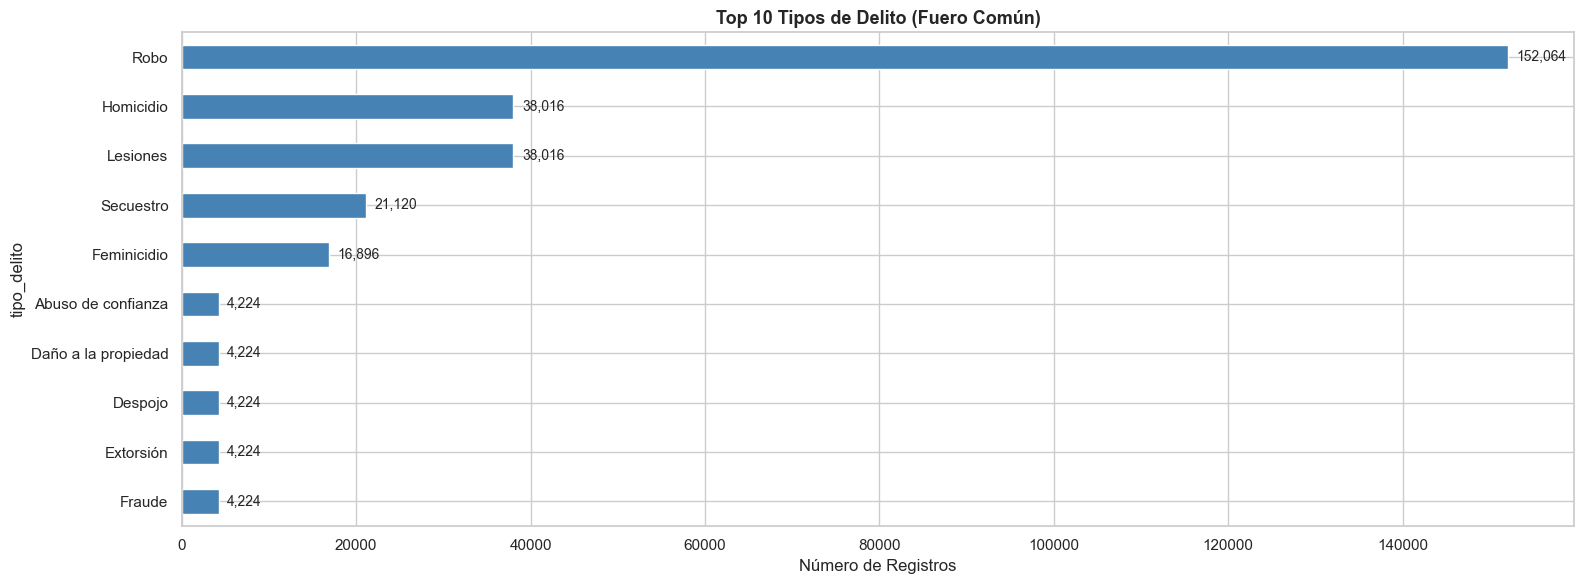

In [62]:
crime_counts = dataframe["tipo_delito"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(16, 6))
crime_counts.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 10 Tipos de Delito (Fuero Común)", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de Registros")
ax.invert_yaxis()

# Añade valores en las barras
for i, v in enumerate(crime_counts.values):
    ax.text(v + 1000, i, f"{v:,}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

En cuanto a las variables categóricas del conjunto de datos podemos notar hechos bastante interesantes a pesar de la inmensidad del dataset:
- El dataset es de 11 años, sin embargo, solo hay 132 fechas únicas, con la más frecuente siendo el 01 de Abril de 2025
- La moda del dataset tiene algunos resultados curiosos. Este conjunto de datos es simetrico para cada estado, ya que existen 12936 líneas para c/u. Entonces, al querer cálcular la moda se toma el valor inicial de manera alfabética y resulta ser Aguascalientes. Sin embargo, esto no significa que sea la entidad con mayor apariciones del dataset.
- Lo anterior pasa de igual manera con la fecha, ya que toma la primera fecha del dataset para calcular este valor.
- El dataset reporta 40 tipos de delitos únicos reportados, con Robo siendo la categoría principal. 

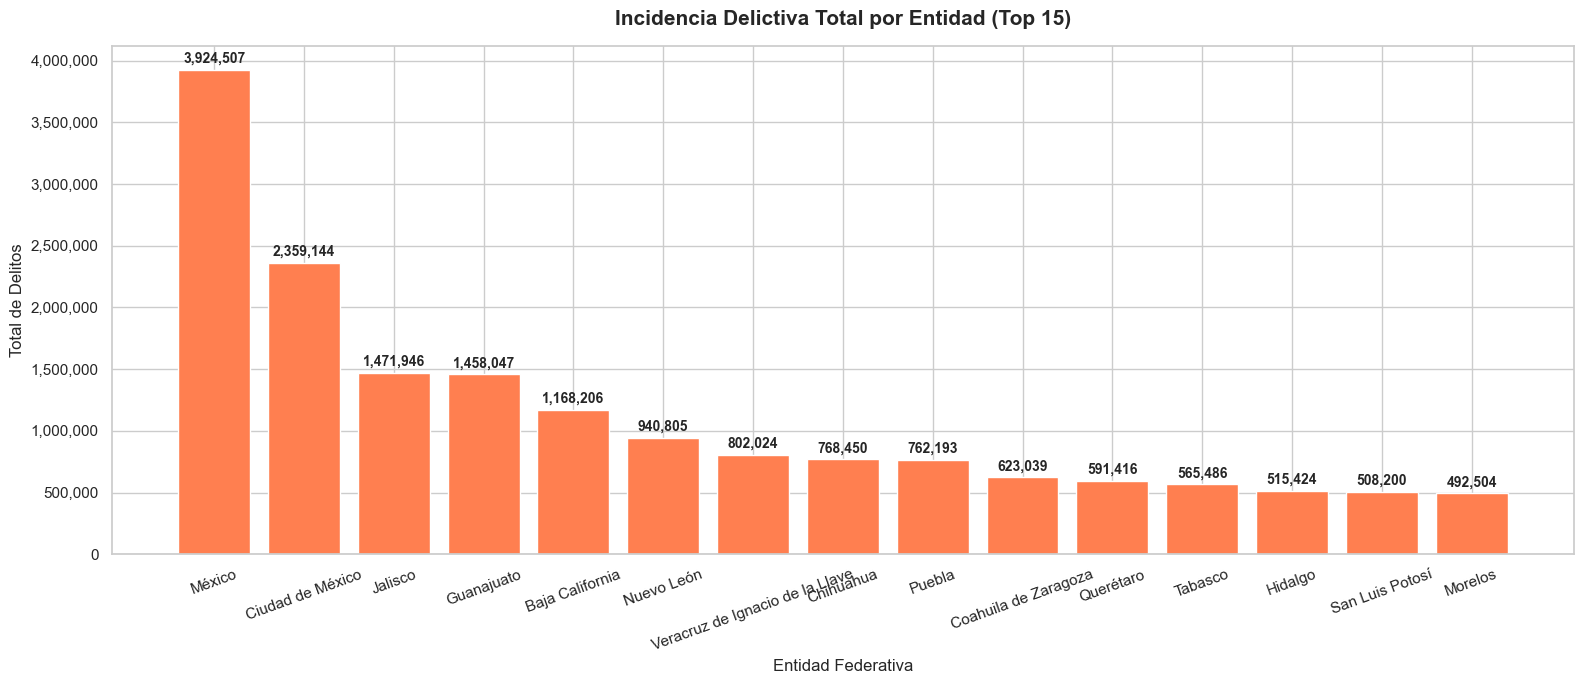

In [72]:
from matplotlib.ticker import StrMethodFormatter

entidad_counts = (
    dataframe.groupby("entidad")["incidencia_delictiva"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(16, 7))
bars = ax.bar(entidad_counts.index, entidad_counts.values, color="coral")
# Formato del eje Y con separadores de miles y sin decimales
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
# Agregamos los valores reales arriba de cada barra con separadores de miles
ax.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=10, fontweight="bold")

ax.set_title(
    "Incidencia Delictiva Total por Entidad (Top 15)",
    fontsize=15,
    fontweight="bold",
    pad=15,
)
ax.set_ylabel("Total de Delitos", fontsize=12)
ax.set_xlabel("Entidad Federativa", fontsize=12)
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## Detección de Valores Atípicos

- IQR La incidencia delictiva está fuertemente sesgada a la derecha (CDMX y Edomex disparan los valores frente a estados pequeños). El z-score asume normalidad y los propios extremos inflan media y desviación, así que reporta resultados sesgados; IQR es robusto a colas largas y coincide con lo que dibuja el boxplot.
- Tratamiento: marcar, no eliminar. En estos datos los outliers no son errores de captura: son señales reales. Eliminarlos distorsionaría el análisis. La clase ofrece además ``winsorize`` (recorte a los límites) y ``drop`` (eliminación de filas) para cuando se justifique.

In [73]:
det = OutlierDetector(dataframe, columns=["incidencia_delictiva"])
det.summary()

,columna,n_total,min,max,lower,upper,n_outliers,pct_outliers
0,incidencia_delictiva,413952,0.0,9968.0,-39.0,65.0,63128,15.250077


In [74]:
det.flag()

,fecha,entidad,bien_juridico_afectado,tipo_delito,subtipo_delito,modalidad,incidencia_delictiva,incidencia_delictiva_is_outlier
0,2015-04-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,22,False
1,2015-08-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,40,False
2,2015-12-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,26,False
3,2015-01-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,41,False
4,2015-02-01,Aguascalientes,El patrimonio,Abuso de confianza,Abuso de confianza,Abuso de confianza,33,False
...,...,...,...,...,...,...,...,...
413947,2025-03-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,184,True
413948,2025-05-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,98,True
413949,2025-11-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,92,True
413950,2025-10-01,Zacatecas,Otros bienes jurídicos afectados (del fuero común),Otros delitos del Fuero Común,Otros delitos del Fuero Común,Otros delitos del Fuero Común,99,True


## Distribuciones

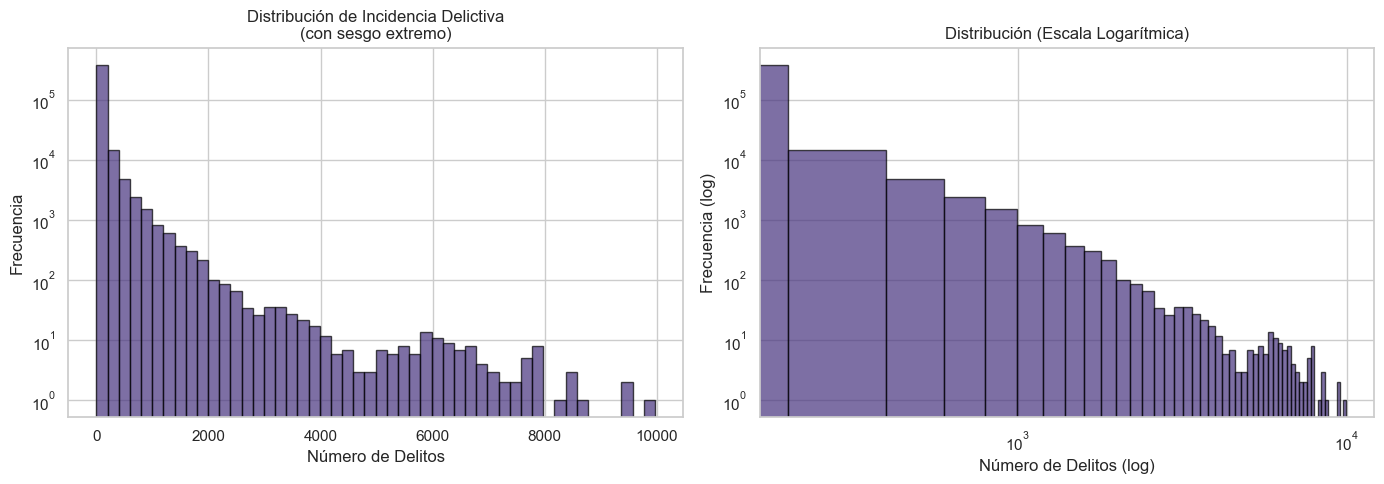

In [8]:
# Histograma + KDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(dataframe["incidencia_delictiva"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_title(
    "Distribución de Incidencia Delictiva\n(con sesgo extremo)", fontsize=12
)
axes[0].set_xlabel("Número de Delitos")
axes[0].set_ylabel("Frecuencia")
axes[0].set_yscale("log")  # Escala log para ver mejor

axes[1].hist(dataframe["incidencia_delictiva"], bins=50, edgecolor="black", alpha=0.7)
axes[1].set_title("Distribución (Escala Logarítmica)", fontsize=12)
axes[1].set_xlabel("Número de Delitos (log)")
axes[1].set_ylabel("Frecuencia (log)")
axes[1].set_xscale("log")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

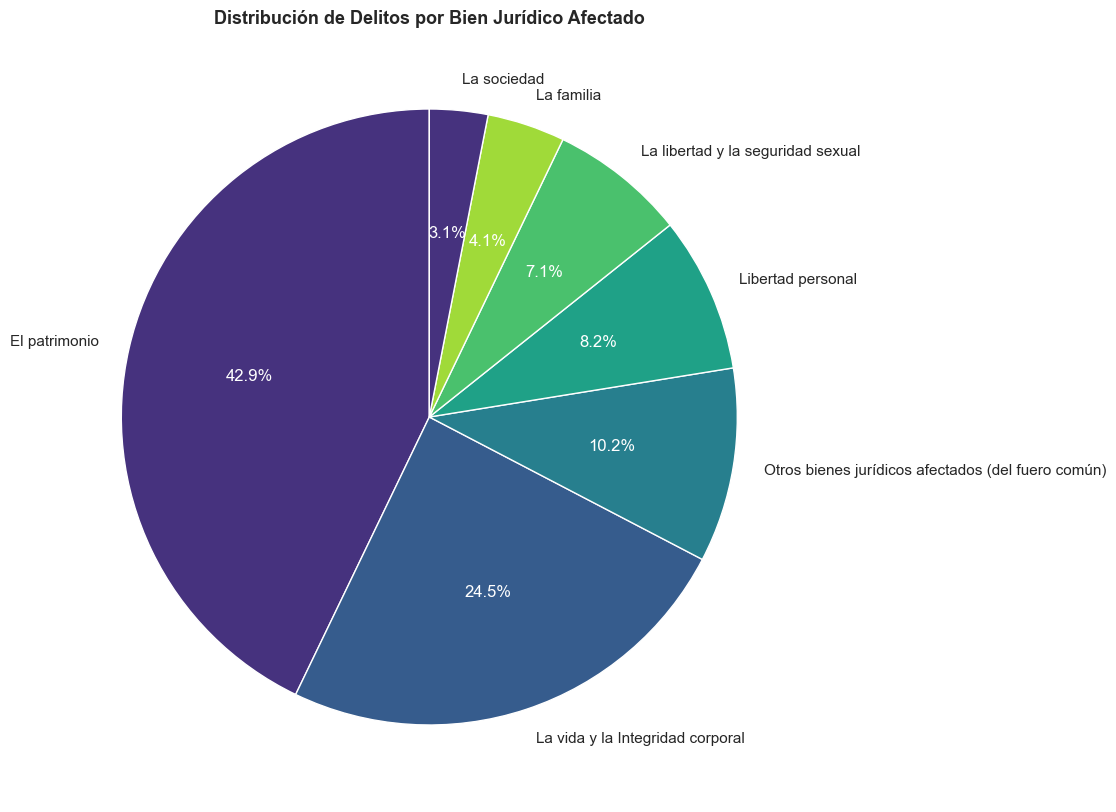

In [32]:
bien_juridico = dataframe["bien_juridico_afectado"].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    bien_juridico.values, labels=bien_juridico.index, autopct="%1.1f%%", startangle=90
)
ax.set_title(
    "Distribución de Delitos por Bien Jurídico Afectado", fontsize=13, fontweight="bold"
)
for autotext in autotexts:
    autotext.set_color("white")

plt.show()

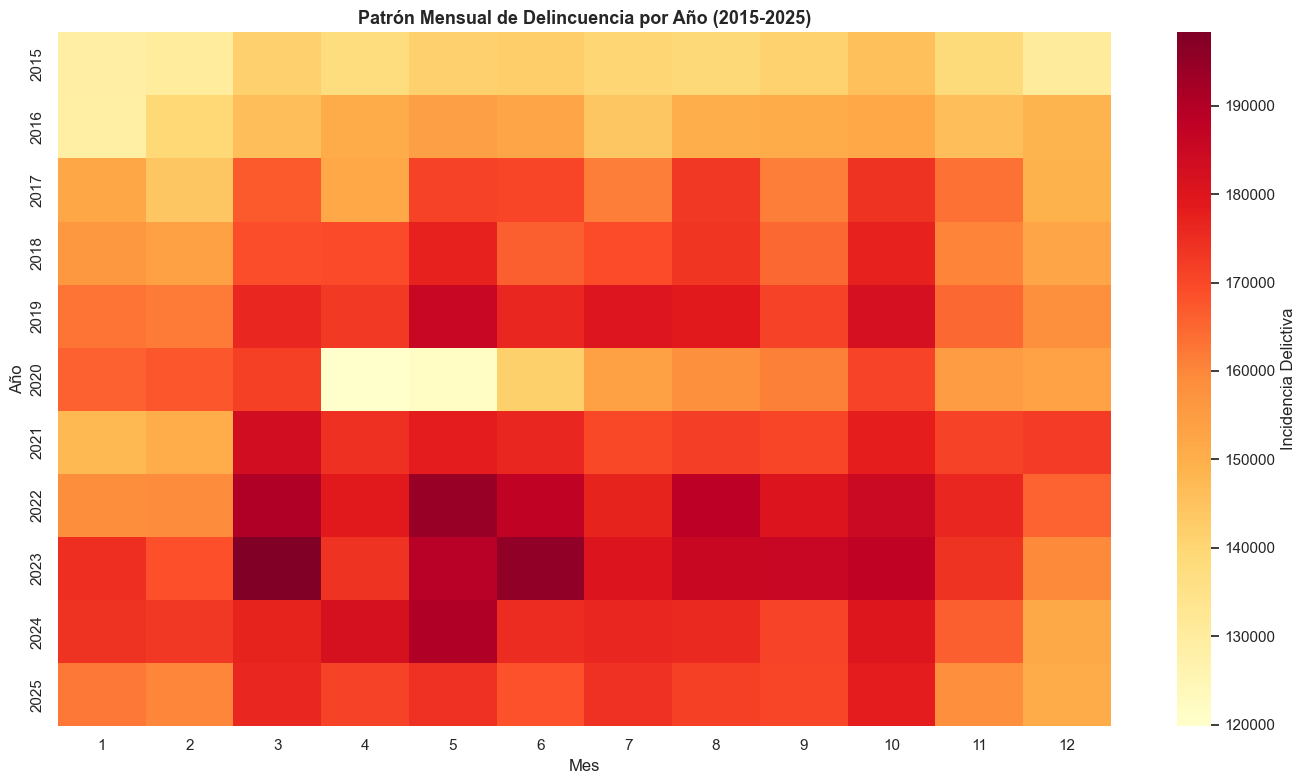

In [34]:
dataframe["fecha"] = pd.to_datetime(dataframe["fecha"])
dataframe["año"] = dataframe["fecha"].dt.year
dataframe["mes"] = dataframe["fecha"].dt.month

pivot_data = dataframe.groupby(["año", "mes"])["incidencia_delictiva"].sum().unstack()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot_data,
    cmap="YlOrRd",
    annot=False,
    fmt="d",
    cbar_kws={"label": "Incidencia Delictiva"},
    ax=ax,
)

ax.set_title(
    "Patrón Mensual de Delincuencia por Año (2015-2025)", fontsize=13, fontweight="bold"
)
ax.set_xlabel("Mes")
ax.set_ylabel("Año")

plt.tight_layout()
plt.show()

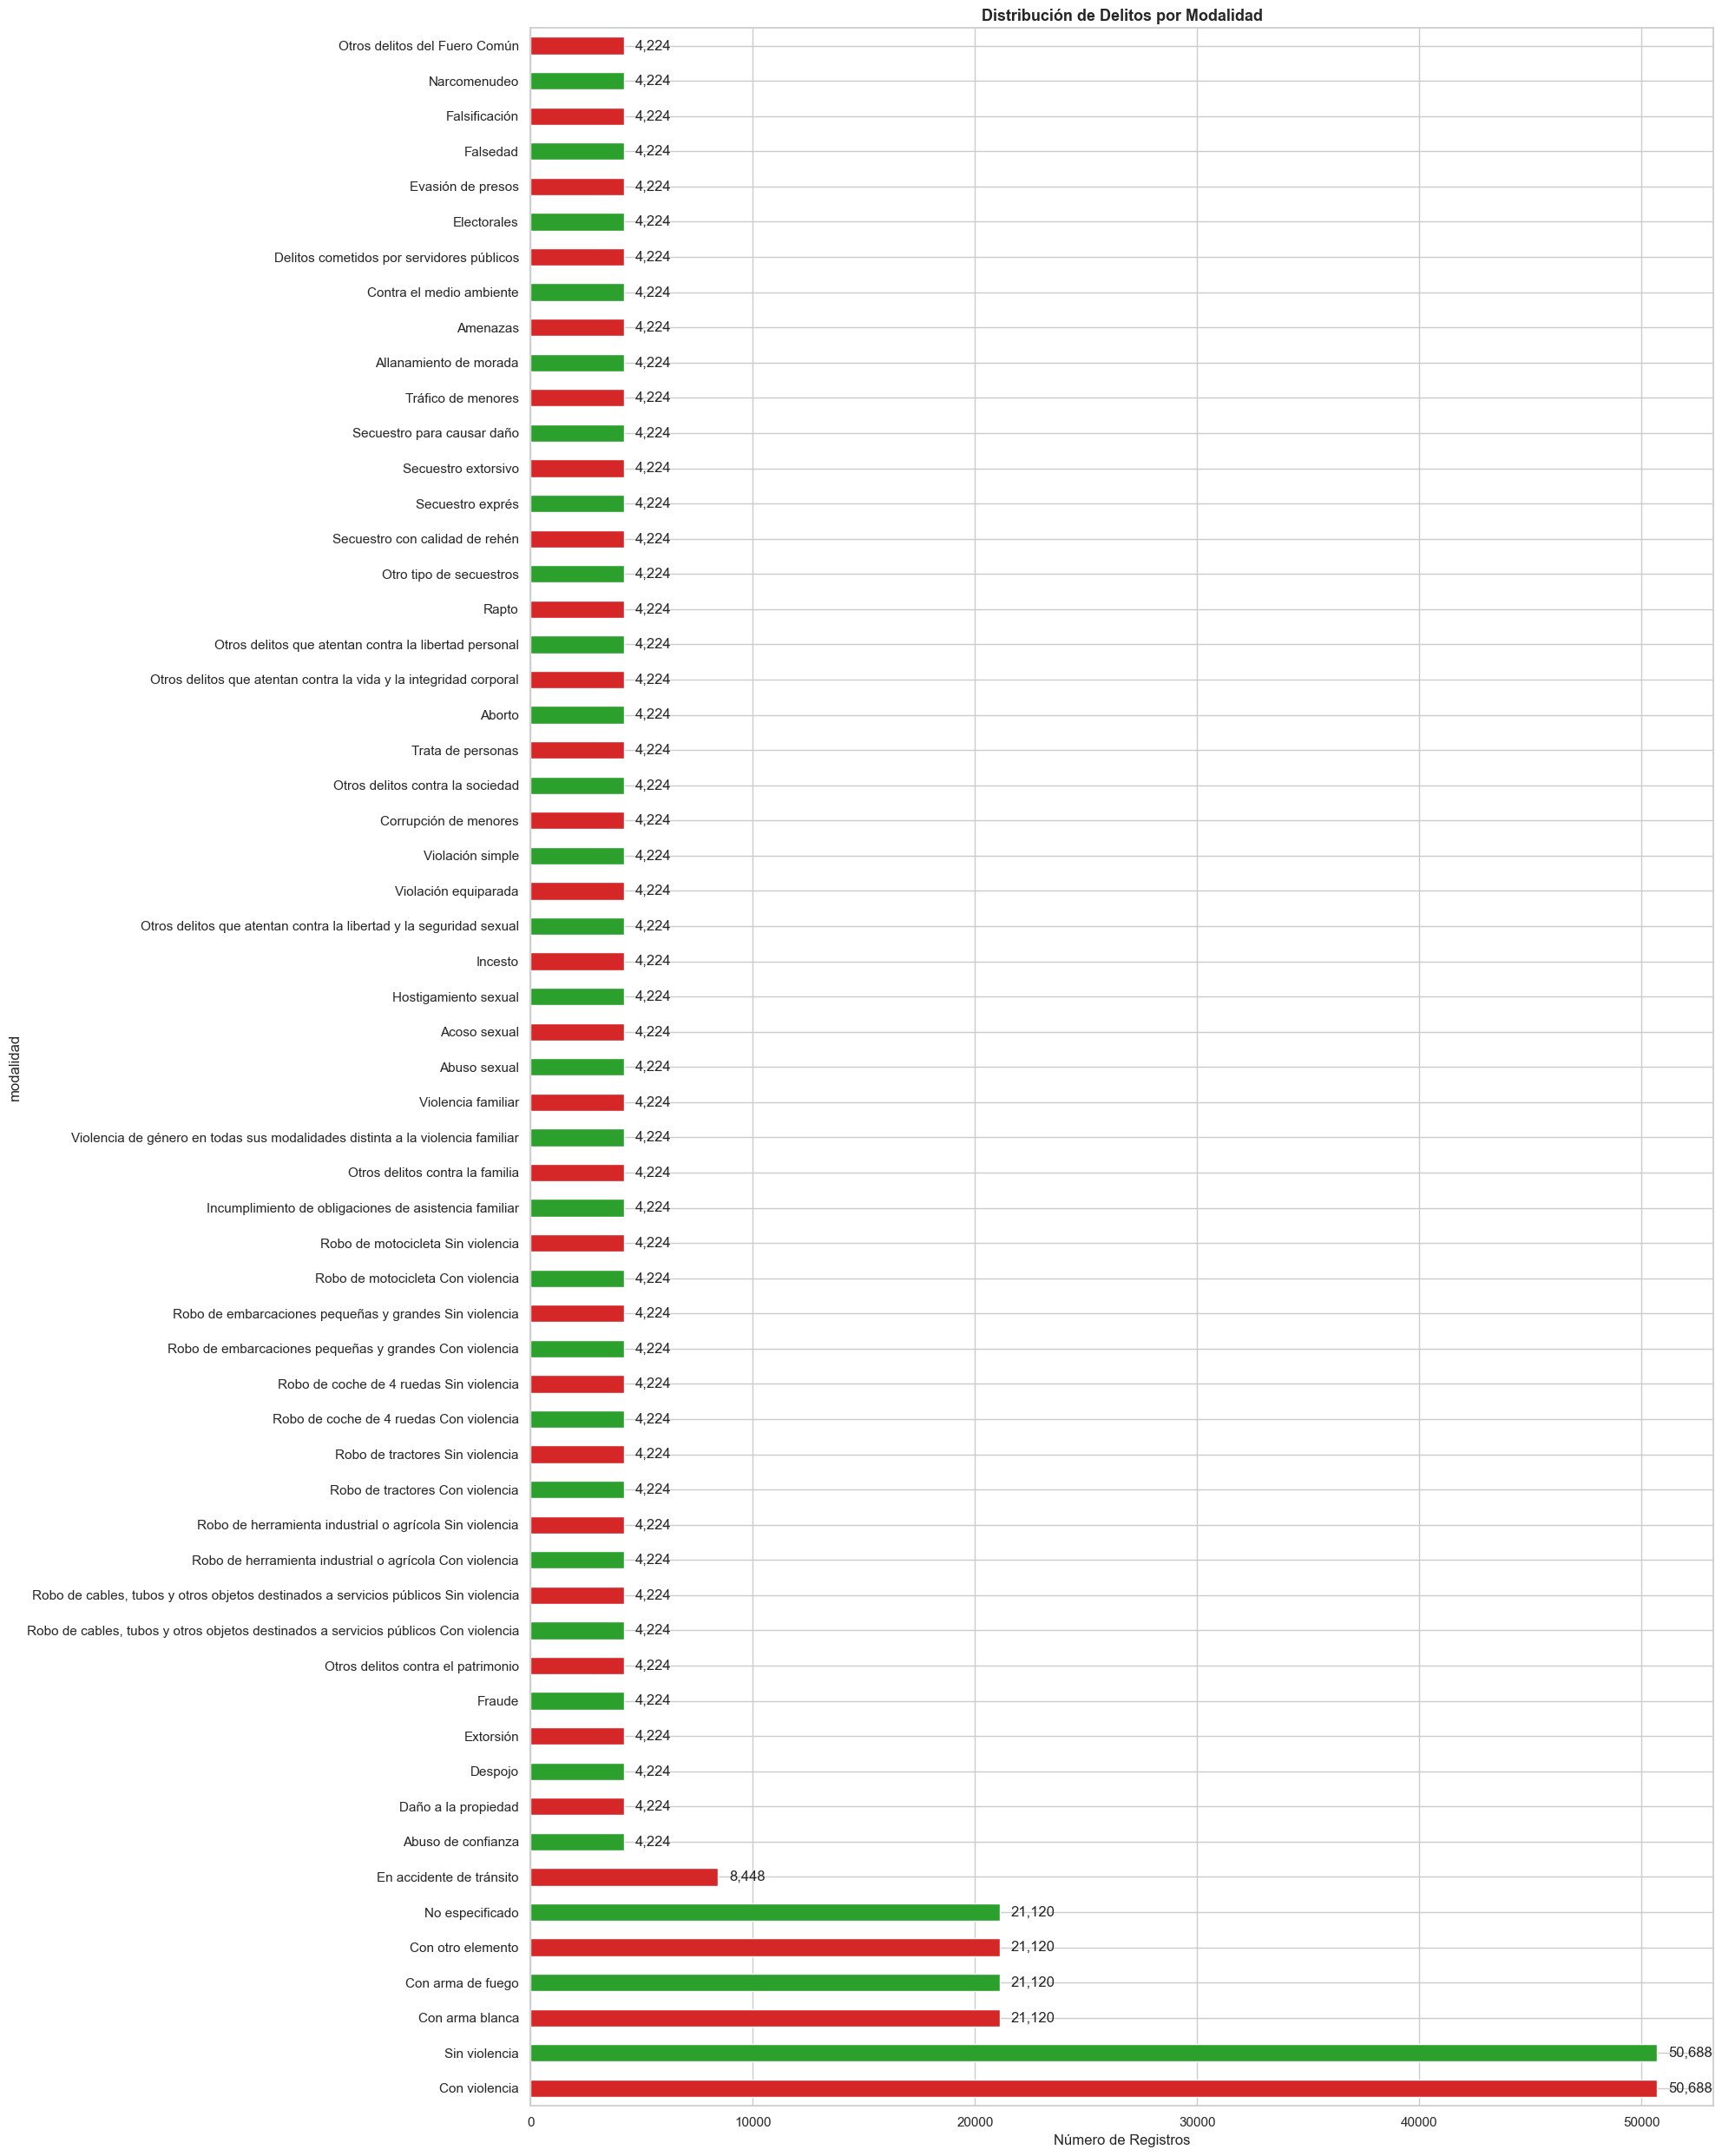

In [40]:
modalidad = dataframe["modalidad"].value_counts()

fig, ax = plt.subplots(figsize=(20, 25))
modalidad.plot(kind="barh", ax=ax, color=["#d62728", "#2ca02c"])

ax.set_title("Distribución de Delitos por Modalidad", fontsize=13, fontweight="bold")
ax.set_xlabel("Número de Registros")

for i, v in enumerate(modalidad.values):
    ax.text(v + 500, i, f"{v:,}", va="center")

plt.tight_layout()
plt.show()

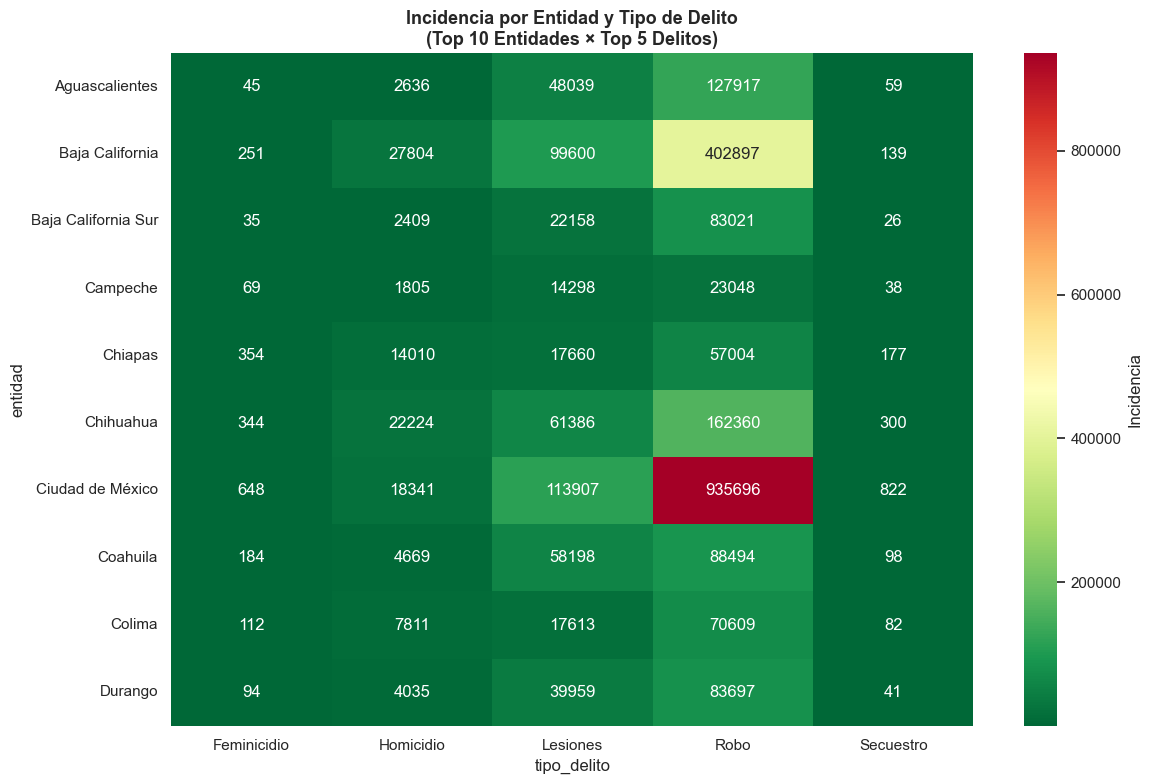

In [41]:
# Top 5 delitos × Top 10 entidades
top_crimes = dataframe["tipo_delito"].value_counts().head(5).index
top_entities = dataframe["entidad"].value_counts().head(10).index

filtered_df = dataframe[
    dataframe["tipo_delito"].isin(top_crimes) & dataframe["entidad"].isin(top_entities)
]

pivot = filtered_df.pivot_table(
    values="incidencia_delictiva", index="entidad", columns="tipo_delito", aggfunc="sum"
)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "Incidencia"},
    ax=ax,
)

ax.set_title(
    "Incidencia por Entidad y Tipo de Delito\n(Top 10 Entidades × Top 5 Delitos)",
    fontsize=13,
    fontweight="bold",
)

plt.tight_layout()
plt.show()

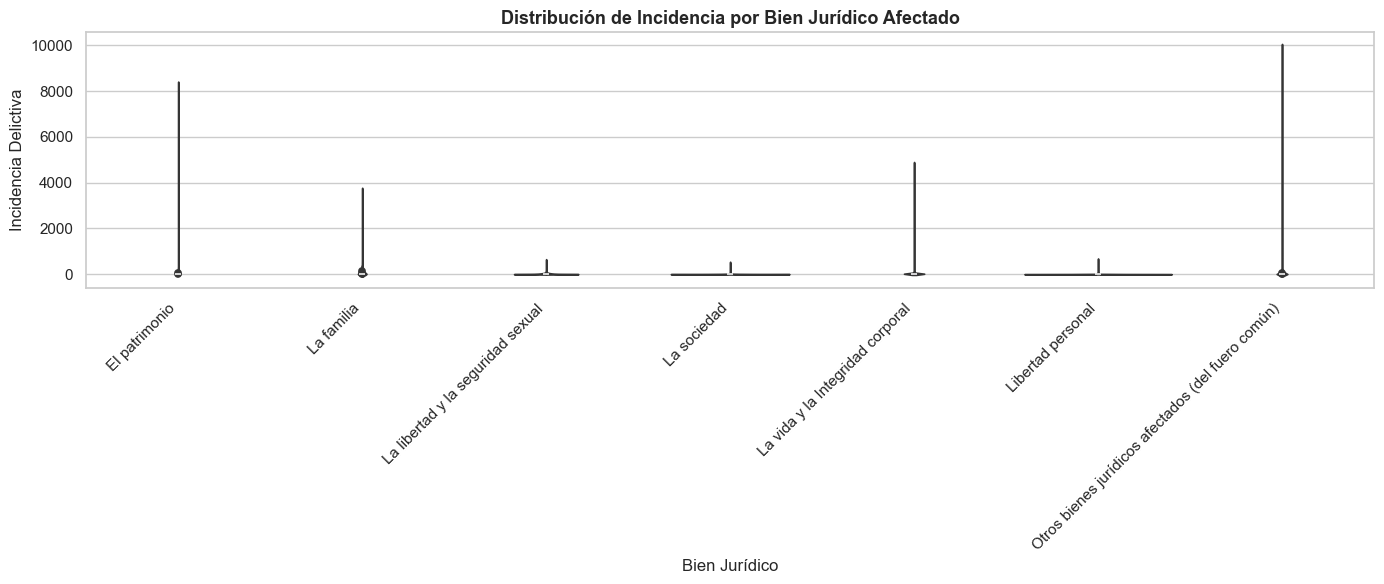

In [43]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.violinplot(
    data=dataframe, x="bien_juridico_afectado", y="incidencia_delictiva", ax=ax
)

ax.set_title(
    "Distribución de Incidencia por Bien Jurídico Afectado",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Bien Jurídico")
ax.set_ylabel("Incidencia Delictiva")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

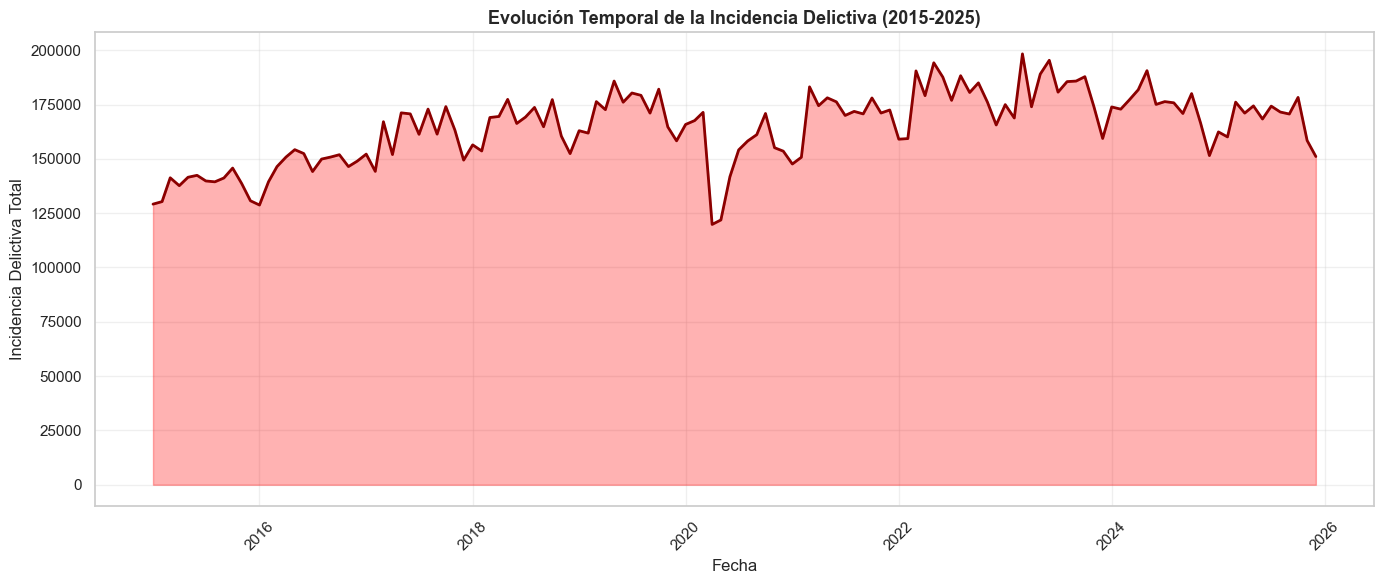

In [48]:
# Agregar por fecha
temporal = dataframe.groupby("fecha")["incidencia_delictiva"].sum().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(temporal.index, temporal.values, linewidth=2, color="darkred")
ax.fill_between(temporal.index, temporal.values, alpha=0.3, color="red")

ax.set_title(
    "Evolución Temporal de la Incidencia Delictiva (2015-2025)",
    fontsize=13,
    fontweight="bold",
)
ax.set_xlabel("Fecha")
ax.set_ylabel("Incidencia Delictiva Total")
ax.grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()